In [1]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

library(knitr)
library(kableExtra)

Loading required package: pacman


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [2]:
hcris_kff <- read_csv("../data/output/hcris_kff.csv")

Rows: 161060 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (5): fy_start, fy_end, date_processed, date_created, expansion_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Problem 1

In [4]:
hcris.kff <- hcris_kff %>% 
  mutate(
    Year = year,
    uncomp_care_m = uncomp_care / 1e6
  )
hcris.kff %>%
  filter(Year >= 2010, Year <= 2018) %>%
  group_by(Year) %>%
  summarize(
    Mean = mean(uncomp_care_m, na.rm = TRUE),
    SD   = sd(uncomp_care_m,   na.rm = TRUE),
    .groups = "drop"
  ) %>%
  kable(
    col.names = c("Year", "Mean ($M)", "Std. Dev. ($M)"),
    digits    = 2,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Uncompensated Care (\\$M), 2010--2018"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table table-condensed" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Uncompensated Care ($mm), 2010–2018</caption>
 <thead>
  <tr>
   <th style="text-align:center;"> Year </th>
   <th style="text-align:center;"> Mean </th>
   <th style="text-align:center;"> SD </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:center;"> 2010 </td>
   <td style="text-align:center;"> 30.26 </td>
   <td style="text-align:center;"> 72.26 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> 2011 </td>
   <td style="text-align:center;"> 34.10 </td>
   <td style="text-align:center;"> 74.96 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> 2012 </td>
   <td style="text-align:center;"> 37.54 </td>
   <td style="text-align:center;"> 86.63 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> 2013 </td>
   <td style="text-align:center;"> 39.43 </td>
   <td style="text-align:center;"> 80.86 </td>
  </tr>
  <tr>
   <td style="text-align:center

## Problem 2

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Removed 15 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 15 rows containing missing values (`geom_point()`).”


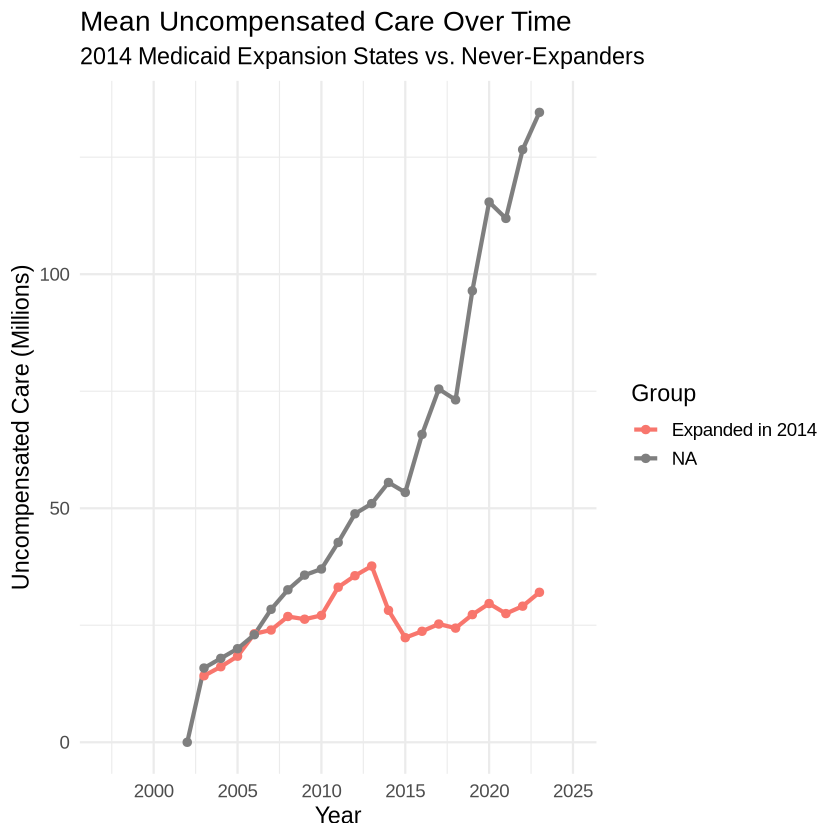

In [5]:
df <- hcris_kff %>% mutate(expansion_year = year(expansion_date), 
                           uncomp_care_m = uncomp_care / 1e6)

df_filtered <- df %>%
  filter(
    expansion_year == 2014 | is.na(expansion_year)   
      # keep 2014 expanders + never-expanders
  ) %>%
  mutate(
    group = if_else(expansion_year == 2014, "Expanded in 2014", "Never Expanded")
  )

df_summary <- df_filtered %>%
  group_by(year, group) %>%
  summarize(
    mean_uc = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(df_summary, aes(x = year, y = mean_uc, color = group)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(
    title = "Mean Uncompensated Care Over Time",
    subtitle = "2014 Medicaid Expansion States vs. Never-Expanders",
    x = "Year",
    y = "Uncompensated Care (Millions)",
    color = "Group"
  ) +
  theme_minimal(base_size = 14)

## Problem 3

In [6]:
df <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    uncomp_care_m = uncomp_care / 1e6,
    group = case_when(
      expansion_year == 2014 ~ "Treatment",
      is.na(expansion_year) ~ "Control"
    )
  ) %>%
  filter(group %in% c("Treatment", "Control"))  # drop post-2014 expanders

dd_table <- df %>%
  filter(year %in% c(2012, 2015)) %>%
  group_by(group, year) %>%
  summarize(
    mean_uc = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(
    names_from = year,
    values_from = mean_uc,
    names_prefix = "Year_"
  )

dd_table %>%
  mutate(
    Difference = Year_2015 - Year_2012
  ) %>%
  kable(
    col.names = c("Group", "2012 ($M)", "2015 ($M)", "Difference ($M)"),
    digits    = 2,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Difference-in-Differences: Mean Uncompensated Care (\\$M)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Difference-in-Differences: Mean Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Group </th>
   <th style="text-align:right;font-weight: bold;"> 2012 ($M) 
   </th>
<th style="text-align:right;font-weight: bold;"> 2015 ($M) </th>
   <th style="text-align:right;font-weight: bold;"> Difference ($M) </th>
  
 

</tr>
</thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Control </td>
   <td style="text-align:right;"> 48.81 </td>
   <td style="text-align:right;"> 53.38 </td>
   <td style="text-align:right;"> 4.57 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment </td>
   <td style="text-align:right;"> 35.58 </td>
   <td style="text-align:right;"> 22.35 </td>
   <td style="text-align:right;"> -13.24 </td>
  </tr>
</tbody>
</table>

## Problem 4

The adoption of Medicaid leads to a decrease in uncompensated care, as observed. Thus, we expect this effect as it encourages hospitals to take Medicare patients and get compensation or partial support from the Medicare program, instead of outsourcing debt to manage or counter their listed charges to a third-party bank.

# Estimate ATEs

## Problem 5

In [7]:
df_dd <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    post           = if_else(year >= 2014, 1, 0),
    treat          = post * expand_ever
  ) %>%
  filter(
    expansion_year == 2014 | is.na(expansion_year)  # 2014 expanders + never-expanders
  )

model <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = df_dd)

coef_df <- as.data.frame(summary(model)$coefficients)
coef_df$term <- c("Intercept", "Post 2014", "Ever Expanded", "Post x Ever Expanded (DiD)")
coef_df <- coef_df[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

coef_df$`Pr(>|t|)` <- paste0(
  formatC(coef_df$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_df$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)

kable(
  coef_df,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "DiD Estimates: Effect of Medicaid Expansion on Uncompensated Care (\\$M)"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(4, bold = TRUE)


Call:
lm(formula = uncomp_care_m ~ post + expand_ever + post * expand_ever, 
    data = df_dd)

Residuals:
    Min      1Q  Median      3Q     Max 
-178.04  -25.19  -18.37    1.93 3129.71 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       31.7255     0.9695  32.722  < 2e-16 ***
post              48.5244     1.5762  30.786  < 2e-16 ***
expand_ever       -5.9650     1.2511  -4.768 1.87e-06 ***
post:expand_ever -48.2655     2.0158 -23.943  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 89.76 on 35115 degrees of freedom
  (85606 observations deleted due to missingness)
Multiple R-squared:  0.04248,	Adjusted R-squared:  0.04239 
F-statistic: 519.2 on 3 and 35115 DF,  p-value: < 2.2e-16


<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>DiD Estimates: Effect of Medicaid Expansion on Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:right;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Intercept </td>
   <td style="text-align:right;"> 31.725 </td>
   <td style="text-align:right;"> 0.970 </td>
   <td style="text-align:right;"> 32.722 </td>
   <td style="text-align:right;"> 0 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Post 2014 </td>
   <td style="text-align:right;"> 48.524 </td>
   <td style="text-align:right;"> 1.576 </td>
   <td style="text-align:right;">

## Problem 6

In [8]:
library(fixest)

m.twfe <- feols(uncomp_care_m ~ treat | provider_number + year,
                data = df_dd,
                cluster = ~ state)

coef_twfe <- as.data.frame(summary(m.twfe)$coeftable)
coef_twfe$term <- "Treatment (DiD)"
coef_twfe <- coef_twfe[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

coef_twfe$`Pr(>|t|)` <- paste0(
  formatC(coef_twfe$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_twfe$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)

kable(
  coef_twfe,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "TWFE Estimates: Effect of Medicaid Expansion on Uncompensated Care (\\$M)"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  add_footnote(
    c("Hospital and year fixed effects included.",
      "Standard errors clustered at the state level."),
    notation = "none"
  )

NOTE: 85,606 observations removed because of NA values (LHS: 85,606, vcov: 284).



OLS estimation, Dep. Var.: uncomp_care_m
Observations: 35,119 
Fixed-effects: provider_number: 3,984,  year: 22
Standard-errors: Clustered (state) 
      Estimate Std. Error  t value   Pr(>|t|)    
treat -52.6967    10.2054 -5.16362 7.9551e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 50.7     Adj. R2: 0.655034
             Within R2: 0.044802

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>TWFE Estimates: Effect of Medicaid Expansion on Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:right;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment (DiD) </td>
   <td style="text-align:right;"> -52.697 </td>
   <td style="text-align:right;"> 10.205 </td>
   <td style="text-align:right;"> -5.164 </td>
   <td style="text-align:right;"> 0 </td>
  </tr>
</tbody>
<tfoot>
<tr>
<td style = 'padding: 0; border:0;' colspan='100%'><sup></sup> Hospital and year fixed effects included.</td>
</tr>
<tr>
<td style = 'padding: 0; border:0;' colspan='100

We notice that both the estimators yield near about same magnitude of estimated effect around 48 to 52 millions of uncompensated care.

## Problem 7

In [12]:
df_dd2 <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    post           = if_else(year >= 2014, 1, 0),
    treat          = if_else(!is.na(expansion_year) & year >= expansion_year, 1, 0)
  )

model2 <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = df_dd2)

m.twfe2 <- feols(uncomp_care_m ~ treat | provider_number + year,
                 data = df_dd2,
                 cluster = ~ state)

# --- OLS Table ---
coef_ols2 <- as.data.frame(summary(model2)$coefficients)
coef_ols2$term <- c("Intercept", "Post 2014", "Ever Expanded", "Post x Ever Expanded (DiD)")
coef_ols2$`Pr(>|t|)` <- paste0(
  formatC(coef_ols2$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_ols2$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)
coef_ols2 <- coef_ols2[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

kable(
  coef_ols2,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "OLS DiD: Effect of Medicaid Expansion on Uncompensated Care (\\$M), All States"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(4, bold = TRUE) %>%
  add_footnote("Signif. codes: *** p<0.01, ** p<0.05, * p<0.10", notation = "none")

# --- TWFE Table ---
coef_twfe2 <- as.data.frame(summary(m.twfe2)$coeftable)
coef_twfe2$term <- "Treatment (DiD)"
coef_twfe2$`Pr(>|t|)` <- paste0(
  formatC(coef_twfe2$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_twfe2$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)
coef_twfe2 <- coef_twfe2[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

kable(
  coef_twfe2,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "TWFE: Effect of Medicaid Expansion on Uncompensated Care (\\$M), All States"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

NOTE: 114,306 observations removed because of NA values (LHS: 114,306, vcov: 284).



<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS DiD: Effect of Medicaid Expansion on Uncompensated Care (\$M), All States</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Intercept </td>
   <td style="text-align:right;"> 31.725 </td>
   <td style="text-align:right;"> 1.352 </td>
   <td style="text-align:right;"> 23.463 </td>
   <td style="text-align:left;"> 4.94e-121 *** </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Post 2014 </td>
   <td style="text-align:right;"> 48.524 </td>
   <td style="text-align:right;"> 2.198 </td>
   <td style="tex

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>TWFE: Effect of Medicaid Expansion on Uncompensated Care (\$M), All States</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment (DiD) </td>
   <td style="text-align:right;"> -40.038 </td>
   <td style="text-align:right;"> 9.812 </td>
   <td style="text-align:right;"> -4.081 </td>
   <td style="text-align:left;"> 1.55e-04 *** </td>
  </tr>
</tbody>
</table>

## Problem 8

NOTE: 85,606 observations removed because of NA values (LHS: 85,606, vcov: 284).



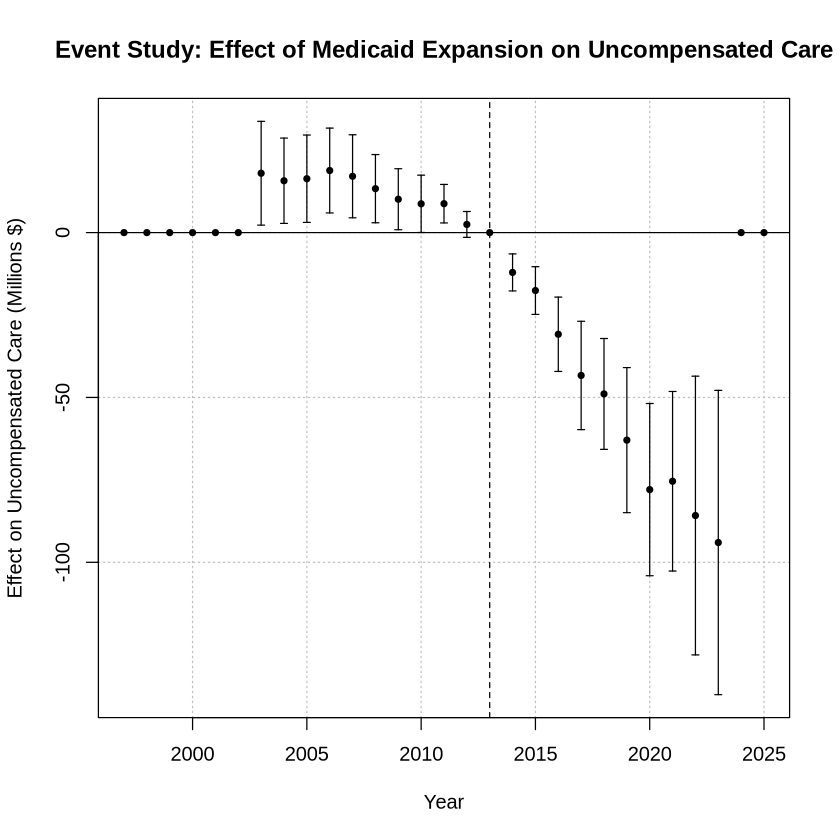

In [10]:
mod.twfe3 <- feols(uncomp_care_m ~ i(year, expand_ever, ref = 2013) | provider_number + year,
                  cluster = ~ state,
                  data = df_dd)

iplot(mod.twfe3,
      xlab = "Year",
      ylab = "Effect on Uncomp Care (M$)",
      main = "Event Study")

## Problem 9

NOTE: 114,306 observations removed because of NA values (LHS: 114,306, vcov: 284).



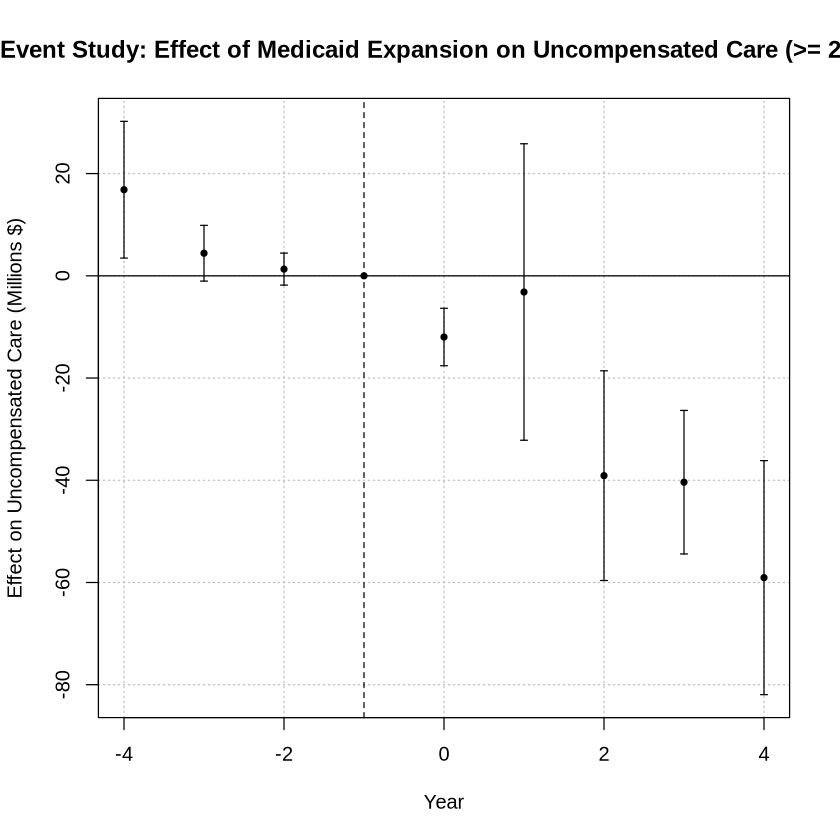

In [11]:
df_dd3 <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    # time relative to EACH STATE'S expansion year
    event_time     = year - expansion_year
    # never-expanders get NA here
  )

df_dd3 <- df_dd3 %>%
  mutate(
    event_time = case_when(
      is.na(expansion_year) ~ -1,   # never-expanders coded as "always pre"
      event_time < -4 ~ -4,          # bin anything beyond -4 into -4
      event_time > 4  ~  4,          # bin anything beyond +4 into +4
      TRUE ~ event_time
    )
  )

mod.twfe4 <- feols(
  uncomp_care_m ~ i(event_time, expand_ever, ref = -1) | provider_number + year,
  cluster = ~ state,
  data = df_dd3
)

iplot(mod.twfe4,
      xlab = "Year",
      ylab = "Effect on Uncomp Care (M$)",
      main = "Event Study (>= 2014)")

## Problem 10

Medicaid expansion leads to a decrease in uncompensated care for hospitals in states that have adopted the change in policy. The event study graph is concerning because the bars for pre-treatment inch away from the zero margin, showing a violation of the parallel trends assumption. One primary limitation of the TWFE estimator is its biased nature in the context of staggered Medicaid expansion, as it does